In [1]:
import pandas as pd
df = pd.read_csv('data/material_labor_index.csv')

In [2]:
display(df)

,Component,Blades,Blades.1,Nacelles,Nacelles.1,Towers,Towers.1,Monopiles,Array Cables,Array Cables.1,Export Cables,Export Cables.1
0,Import Country,Canada,Denmark,France,Germany,Portugal,Denmark,Germany,Greece,United Kingdom,Italy,Finland
1,Import,1,1,1,1,1,1,1,1,1,1,1
2,US Average,1.29,0.83,0.94,0.97,2.35,0.83,0.97,2.54,1.39,1.34,1.07
3,GL Average,1.29,0.83,0.95,0.97,2.35,0.83,0.97,2.54,1.40,1.34,1.08
4,MN,1.39,0.89,1.02,1.04,2.53,0.89,1.04,2.73,1.50,1.44,1.16
5,WI,1.26,0.81,0.92,0.94,2.29,0.81,0.94,2.48,1.36,1.31,1.05
6,IL,1.23,0.79,0.91,0.93,2.25,0.79,0.93,2.43,1.34,1.28,1.03
7,IN,1.24,0.80,0.91,0.93,2.26,0.80,0.93,2.44,1.34,1.29,1.03
8,MI,1.32,0.85,0.97,0.99,2.41,0.85,0.99,2.61,1.43,1.38,1.11
9,OH,1.29,0.83,0.95,0.97,2.35,0.83,0.97,2.54,1.40,1.34,1.08


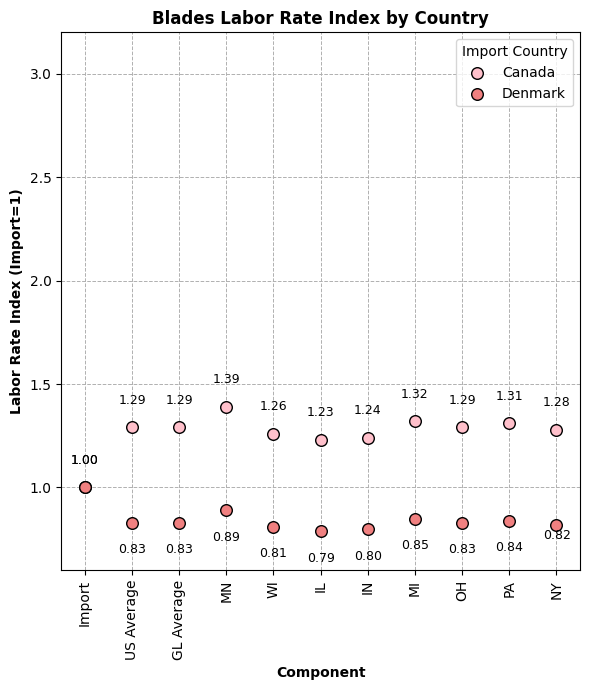

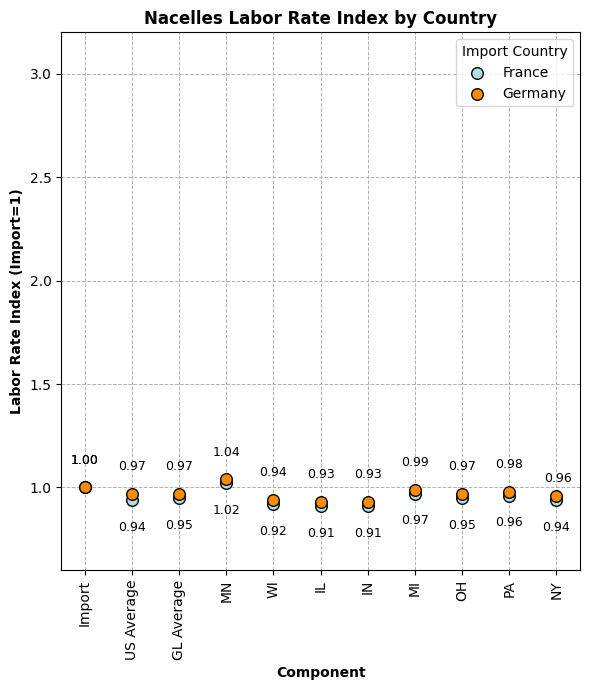

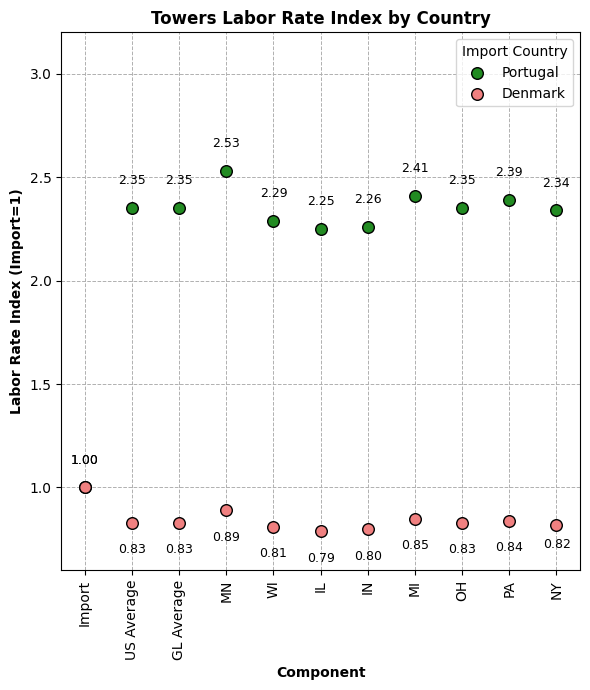

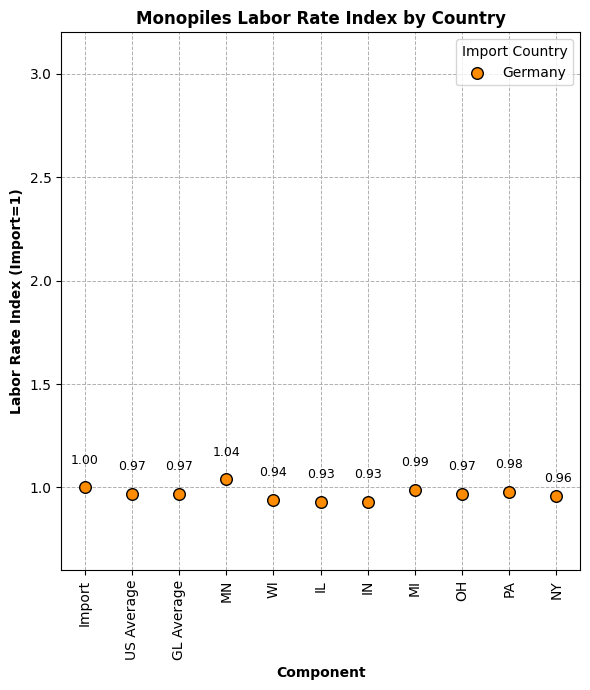

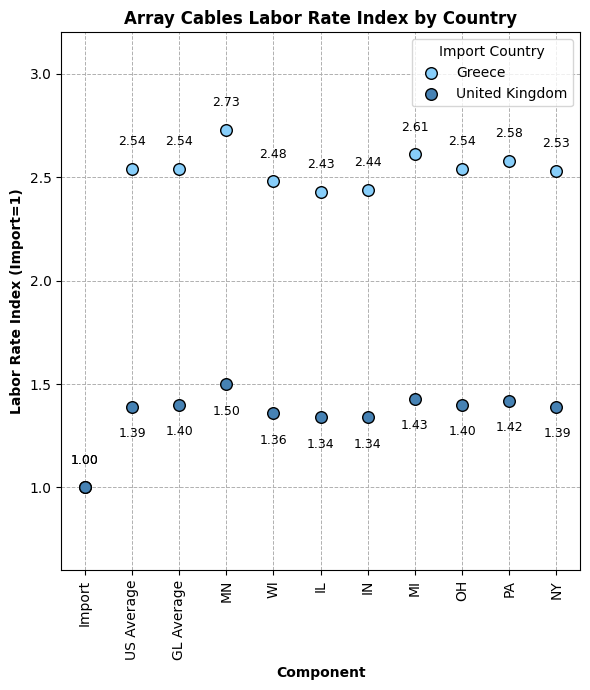

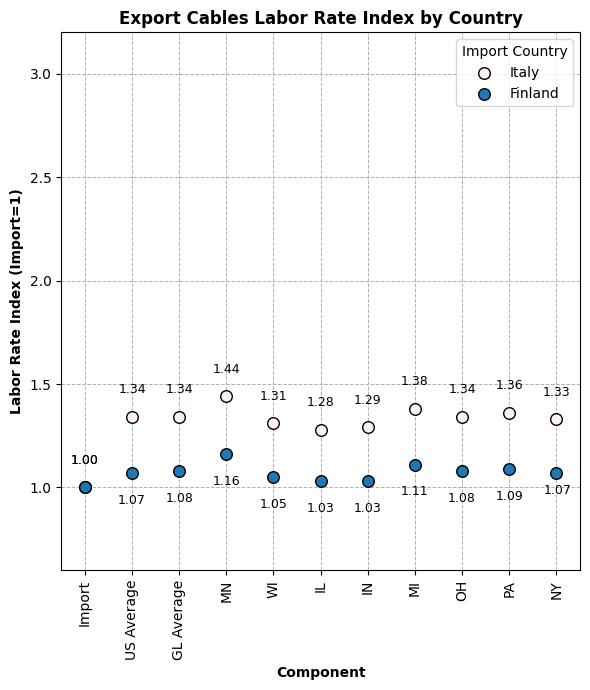

Plots have been saved in the 'figures/labor/' folder.


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from adjustText import adjust_text

# Color mapping based on the countries
color_mapping = {
    "Italy": "lavenderblush",
    "Greece": "lightskyblue",
    "France": "powderblue",
    "Denmark": "lightcoral",
    "Canada": "pink",
    "Germany": "darkorange",
    "Spain": "gold",
    "Portugal": "forestgreen",
    "Netherlands": "lightgrey",
    "South Korea": "beige",
    "Finland": "tab:blue",
    "United Kingdom": "steelblue"
}

# Load the data from CSV
df = pd.read_csv('data/material_labor_index.csv')

# Strip any leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Ensure output directory exists
output_dir = "figures/labor/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Define components to plot
components = ['Blades', 'Nacelles', 'Towers', 'Monopiles', 'Array Cables', 'Export Cables']

# Function to plot each component's data
def plot_component_data(component_name):
    fig, ax = plt.subplots(figsize=(6, 7))
    
    # Extract relevant data for the current component
    component_columns = [col for col in df.columns if component_name in col]
    
    # Extract the row indices we want for the x-axis labels (e.g., "Import", "US Average", etc.)
    x_vals = df.iloc[1:, 0].values  # Use rows 1 and onward for "Import", "US Average", etc.
    
    # Create a scatter plot for each country and plot its data
    for country_column in component_columns:
        # The country name is the column name without the suffix (e.g., "Blades" from "Blades.1")
        country_name = df[country_column].iloc[0]  # Get the country name from the first row

        # Convert values to float and remove any invalid data
        y_vals = pd.to_numeric(df[country_column].iloc[1:].values, errors='coerce')  # Convert to float
        
        # Scatter plot for the component and country
        ax.scatter(x_vals, y_vals, label=country_name, color=color_mapping.get(country_name, 'gray'), edgecolor='black', zorder = 100, s = 70)

    # Now, place labels based on the highest and lowest values for each x value
    for i, x in enumerate(x_vals):
        y_vals_at_x = [pd.to_numeric(df[component_columns[j]].iloc[i+1], errors='coerce') for j in range(len(component_columns))]
        
        # Find the max and min y-values for this x-value
        max_y = max(y_vals_at_x)
        min_y = min(y_vals_at_x)

        # Add labels above the highest point and below the lowest point
        for j, country_column in enumerate(component_columns):
            country_name = df[country_column].iloc[0]
            y = y_vals_at_x[j]
            
            label = f"{y:.2f}"  # Format the label to 2 decimal places
            
            if y == max_y:
                offset_y = 0.1  # Place label above for max
                va = 'bottom'
            elif y == min_y:
                offset_y = -0.1  # Place label below for min
                va = 'top'
            else:
                offset_y = 0  # Default placement for other points
                va = 'center'
            
            text = ax.text(i, y + offset_y, label, fontsize=9, ha='center', va=va, zorder=101)

    # Adjust label positions to avoid overlap
    adjust_text(texts=[text], only_move={'points': 'xy', 'text': 'xy'}, ax=ax, expand_text=(1.05, 1.1), force_text=(0.05, 0.05))
    
    plt.grid(axis='y', linestyle='--', linewidth=0.7, zorder = 1)
    plt.grid(axis='x', linestyle='--', linewidth=0.7, zorder = 1)
    ax.set_ylim([0.6, 3.2])
    ax.set_xlabel('Component', fontweight='bold')
    ax.set_ylabel('Labor Rate Index (Import=1)', fontweight='bold')
    ax.set_title(f'{component_name} Labor Rate Index by Country', fontweight='bold')
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_vals, rotation=90, ha="center")
    ax.legend(title="Import Country")

    # Save the figure
    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, f'{component_name}.png'))
    plt.show()

# Plot each component and save the figure
for component in components:
    plot_component_data(component)

print("Plots have been saved in the 'figures/labor/' folder.")

